## __Data Science: Capstone Part 1: Lightning Talk 1__

### Overview

In the field of data science, good projects are practical. Your capstone project should be manageable and affect a real world audience. This might be a domain you are familiar with, a particular interest you have, something that affects a community you are involved in, or an area that relates to a field you wish to work in.

One of the best ways to test ideas quickly is to share them with others. A good data scientist has to be comfortable discussing ideas and presenting to audiences. That's why for Part 1 of your Capstone project, you'll be preparing a lightning talk on some potential interest areas and datasets.

This deliverable will provide you with guidance to help you select an awesome topic and begin to build a polished Capstone project.

__Goal__: Host a lightning talk presentation describing at least three project proposals, including associated data, problem statement, goals, approach, and basic EDA.

### REQUIRED

__Foreach Topic__:
- Problem Statement
- Goals
- Approach
- Data Source(s)
- Data Info. (basic EDA)

Dataset should have __15k+__ rows and __10+__ columns

___Remember, if you can't find data to support your topic, then you can't move forward.___

In [5]:
#from kegal
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
accuracy_score,
roc_auc_score,
confusion_matrix,
classification_report,
recall_score,
precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

import warnings
warnings.filterwarnings('ignore')

In [6]:

def simple_impute(df, strategies=None):
  
    df = df.copy()
    strategies = strategies or {}

    for col in df.columns:
        if df[col].isnull().sum() == 0:
            continue

        if col in strategies:
            val = strategies[col]
            if val == 'median':
                df[col] = df[col].fillna(df[col].median())
            elif val == 'mode':
                df[col] = df[col].fillna(df[col].mode().iloc[0])
            else:
                df[col] = df[col].fillna(val)
            continue

        if pd.api.types.is_numeric_dtype(df[col]):
            df[col] = df[col].fillna(df[col].median())
        else:
            mode_val = df[col].mode()
            df[col] = df[col].fillna(mode_val.iloc[0] if not mode_val.empty else 'Unknown')

    return df

# Topic 1 : Credit Card Fraud Detection

## Problem Statement

Financial institutions and cardholders face billions of dollars in annual losses due to fraudulent credit card transactions. Fraud patterns evolve rapidly and represent an extremely small fraction of total transaction volume, making manual detection inefficient and prone to missing subtle fraudulent behavior.

The primary objective of this project is to build an automated machine learning classification model to accurately identify fraudulent credit card transactions (`is_fraud`) in real-time. By leveraging transaction attributes—such as transaction amount, category, geographic distance between cardholder and merchant, and temporal patterns—the model aims to detect fraudulent activity with high precision and recall, minimizing financial losses while ensuring minimal disruption to legitimate cardholders.

## Data Info
Data Source :https://www.kaggle.com/datasets/dhruvb2028/credit-card-fraud-dataset

## Data Dictionary
| Column                 | Type    | Description |
| ---------------------- | ------- | ------------ |
| trans_date_trans_time  | object  | Timestamp of the transaction |
| merchant               | object  | Name of the merchant |
| category               | object  | Merchant category (e.g. grocery_pos, entertainment) |
| amt                    | float   | Transaction amount ($) |
| city                   | object  | Cardholder's city |
| state                  | object  | Cardholder's state |
| lat / long             | float   | Cardholder's home latitude / longitude |
| city_pop               | int     | Population of cardholder's city |
| job                    | object  | Cardholder's occupation |
| dob                    | object  | Cardholder's date of birth |
| trans_num              | object  | Unique transaction identifier |
| merch_lat / merch_long | float   | Merchant's latitude / longitude |
| is_fraud               | int     | **Target.** 1 = fraudulent transaction, 0 = legitimate |

In [7]:
# start you EDA
import pandas as pd

In [8]:
df = pd.read_csv('./Data/credit_card_frauds.csv')
df.head()

,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [9]:
df.shape

(339607, 15)

In [10]:
df.isnull().sum()

trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [11]:
df.duplicated().sum()

0

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float64
 14  is_fraud               339607 non-nu

In [13]:
df.describe()

,amt,lat,long,city_pop,merch_lat,merch_long,is_fraud
count,339607.000000,339607.000000,339607.000000,3.396070e+05,339607.000000,339607.000000,339607.000000
mean,70.577984,39.718991,-110.622605,1.071409e+05,39.718853,-110.622383,0.005247
std,161.675242,5.094961,12.651370,2.930299e+05,5.130894,12.663998,0.072248
min,1.000000,20.027100,-165.672300,4.600000e+01,19.027422,-166.671575,0.000000
25%,9.600000,36.715400,-120.093600,4.710000e+02,36.817194,-119.823755,0.000000
50%,46.460000,39.617100,-111.098500,1.645000e+03,39.586209,-111.036443,0.000000
75%,83.350000,41.710000,-100.621500,3.543900e+04,42.193072,-100.353096,0.000000
max,28948.900000,66.693300,-89.628700,2.383912e+06,67.510267,-88.629203,1.000000


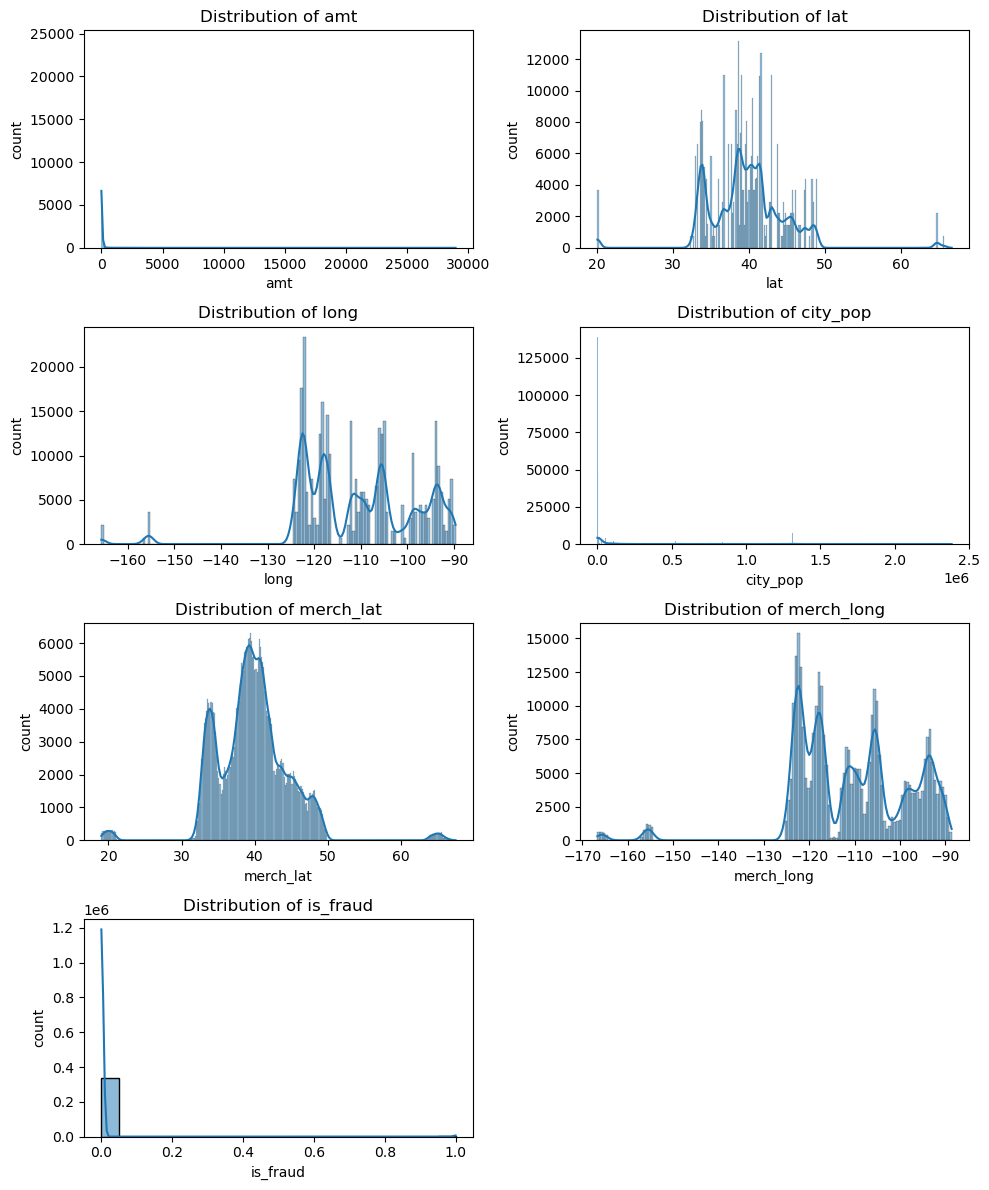

In [14]:
#from kegal
num_cols = df.select_dtypes(include=np.number).columns.tolist()

n_features = len(num_cols)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, n_rows*3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

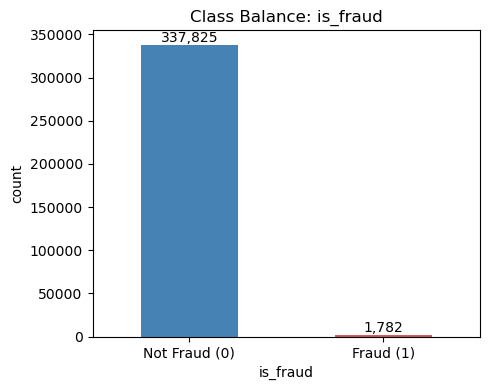

is_fraud
0    99.475276
1     0.524724
Name: proportion, dtype: float64


In [15]:
# Target balance: is_fraud
fig, ax = plt.subplots(figsize=(5, 4))
df['is_fraud'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'indianred'])
ax.set_xticklabels(['Not Fraud (0)', 'Fraud (1)'], rotation=0)
ax.set_ylabel('count')
ax.set_title('Class Balance: is_fraud')
for i, v in enumerate(df['is_fraud'].value_counts()):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

print(df['is_fraud'].value_counts(normalize=True) * 100)

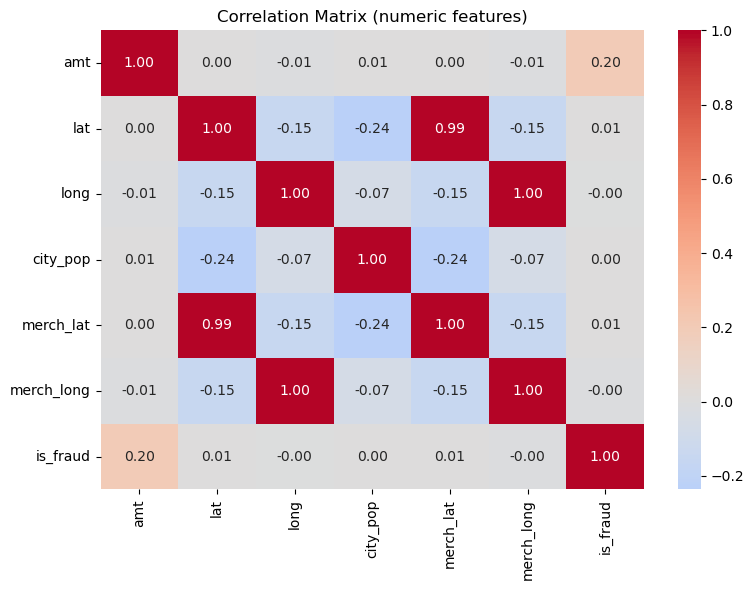

is_fraud      1.000000
amt           0.201023
lat           0.009239
merch_lat     0.008848
city_pop      0.002338
long         -0.004494
merch_long   -0.004550
Name: is_fraud, dtype: float64


In [16]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix (numeric features)')
plt.tight_layout()
plt.show()

print(corr['is_fraud'].sort_values(ascending=False))

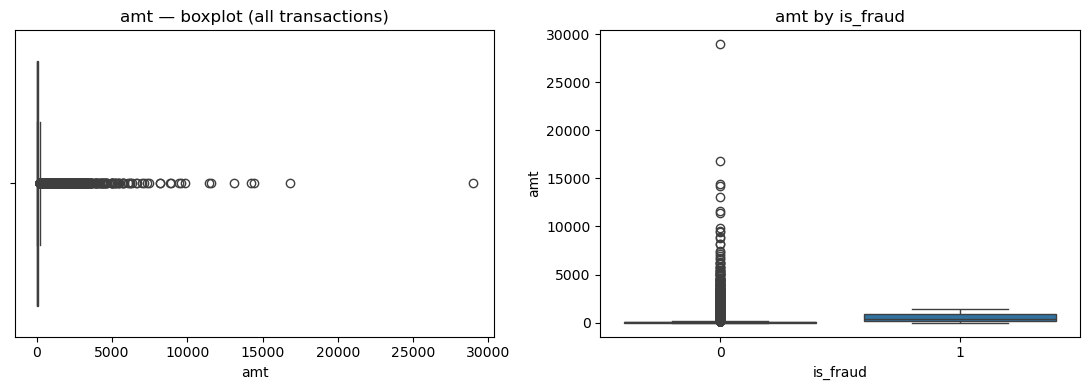

IQR outlier threshold for amt: > 193.97
Rows above threshold: 18043 (5.31%)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df['amt'], ax=axes[0])
axes[0].set_title('amt — boxplot (all transactions)')

sns.boxplot(x='is_fraud', y='amt', data=df, ax=axes[1])
axes[1].set_title('amt by is_fraud')
plt.tight_layout()
plt.show()

q1, q3 = df['amt'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"IQR outlier threshold for amt: > {upper:.2f}")
print(f"Rows above threshold: {(df['amt'] > upper).sum()} ({(df['amt'] > upper).mean()*100:.2f}%)")

In [18]:
# What is your target column and what does it represent? is_fraud — 1 if the transaction was fraudulent, 0 otherwise. It represents the outcome we want to predict
# Is your target categorical or continuous? is it balanced (Plot the distribution)?is_fraud is categorical (binary). It is severely imbalanced: roughly 0.5% of transactions are fraud (mean ≈ 0.0052 from df.describe()), so ~99.5% are legitimate. The plot below shows just how lopsided this is
# What types of features do you have (categorical / numerical)? how many of each ? Numerical: amt, lat, long, city_pop, merch_lat, merch_long (6 features). Categorical: trans_date_trans_time, merchant, category, city, state, job, dob, trans_num (8 features, several high-cardinality like merchant/job/trans_num).
# How many null values does each feature have? what's your plan for each?None — df.isnull().sum() shows 0 missing values across all 15 columns, and there are 0 duplicate rows. No imputation needed.
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them? See the correlation heatmap and boxplots below — amt is right-skewed with a long tail of large-value outliers, and cardholder location (lat/long) is naturally highly correlated with merchant location (merch_lat/merch_long) since most purchases happen near home.

# Topic 2 : Hotel Booking Demand

## Problem Statement

High cancellation rates present a major operational and financial challenge for the hospitality industry, leading to lost revenue, inefficient staff allocation, and pricing complexities. Hotels frequently rely on overbooking strategies to mitigate these losses, which risks damaging customer loyalty and brand reputation when overbooking occurs.

The primary objective of this project is to build an automated machine learning classification model to predict whether a hotel booking will be canceled (`IsCanceled`). By analyzing historical booking data—including lead time, customer demographics, room types, deposit types, and special requests—the model aims to accurately identify high-risk bookings in advance. This enables hotel management to optimize cancellation policies, refine dynamic pricing strategies, and improve overall occupancy forecasting.

## Data Info
Data Source :https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

## Data Dictionary
| Column                          | Type    | Description |
| ------------------------------- | ------- | ------------ |
| hotel                           | object  | Hotel type (Resort Hotel / City Hotel) |
| is_canceled                     | int     | **Target.** 1 = booking was cancelled, 0 = honored |
| lead_time                       | int     | Days between booking date and arrival date |
| arrival_date_year/month/week_number/day_of_month | int/object | Arrival date broken into parts |
| stays_in_weekend_nights / stays_in_week_nights | int | Nights booked on weekends / weekdays |
| adults / children / babies      | int/float | Number of guests by type |
| meal                            | object  | Meal plan booked |
| country                         | object  | Guest's country of origin |
| market_segment / distribution_channel | object | How the booking was made |
| is_repeated_guest               | int     | 1 if guest had booked before |
| previous_cancellations / previous_bookings_not_canceled | int | Guest's booking history |
| reserved_room_type / assigned_room_type | object | Room type requested vs. assigned |
| booking_changes                 | int     | Number of changes made to the booking |
| deposit_type                    | object  | Deposit policy (No Deposit / Non Refund / Refundable) |
| agent / company                 | float/object | Booking agent / company ID (mostly missing) |
| days_in_waiting_list            | int     | Days booking spent on a waiting list |
| customer_type                   | object  | Type of booking (Transient, Group, Contract, etc.) |
| adr                              | float   | Average Daily Rate charged |
| required_car_parking_spaces / total_of_special_requests | int | Guest requests |
| reservation_status / reservation_status_date | object | Final status and date of that status |

In [49]:
H1 = pd.read_csv('./Data/H1.csv')
H1.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,342,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,0,737,2015,July,27,1,0,0,2,0,...,No Deposit,NULL,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,0,7,2015,July,27,1,0,1,1,0,...,No Deposit,NULL,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,0,13,2015,July,27,1,0,1,1,0,...,No Deposit,304,NULL,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,0,14,2015,July,27,1,0,2,2,0,...,No Deposit,240,NULL,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [50]:
H2 = pd.read_csv('./Data/H2.csv')
H2.head()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
0,0,6,2015,July,27,1,0,2,1,0.0,...,No Deposit,6,NULL,0,Transient,0.0,0,0,Check-Out,2015-07-03
1,1,88,2015,July,27,1,0,4,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-07-01
2,1,65,2015,July,27,1,0,4,1,0.0,...,No Deposit,9,NULL,0,Transient,68.0,0,1,Canceled,2015-04-30
3,1,92,2015,July,27,1,2,4,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,2,Canceled,2015-06-23
4,1,100,2015,July,27,2,0,2,2,0.0,...,No Deposit,9,NULL,0,Transient,76.5,0,1,Canceled,2015-04-02


In [63]:

df2 = pd.concat([H1, H2], ignore_index=True)

In [64]:
df2.shape

(119390, 31)

In [67]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   IsCanceled                   119390 non-null  int64  
 1   LeadTime                     119390 non-null  int64  
 2   ArrivalDateYear              119390 non-null  int64  
 3   ArrivalDateMonth             119390 non-null  object 
 4   ArrivalDateWeekNumber        119390 non-null  int64  
 5   ArrivalDateDayOfMonth        119390 non-null  int64  
 6   StaysInWeekendNights         119390 non-null  int64  
 7   StaysInWeekNights            119390 non-null  int64  
 8   Adults                       119390 non-null  int64  
 9   Children                     119386 non-null  float64
 10  Babies                       119390 non-null  int64  
 11  Meal                         119390 non-null  object 
 12  Country                      118902 non-null  object 
 13 

In [65]:
df2.isnull().sum()

IsCanceled                       0
LeadTime                         0
ArrivalDateYear                  0
ArrivalDateMonth                 0
ArrivalDateWeekNumber            0
ArrivalDateDayOfMonth            0
StaysInWeekendNights             0
StaysInWeekNights                0
Adults                           0
Children                         4
Babies                           0
Meal                             0
Country                        488
MarketSegment                    0
DistributionChannel              0
IsRepeatedGuest                  0
PreviousCancellations            0
PreviousBookingsNotCanceled      0
ReservedRoomType                 0
AssignedRoomType                 0
BookingChanges                   0
DepositType                      0
Agent                            0
Company                          0
DaysInWaitingList                0
CustomerType                     0
ADR                              0
RequiredCarParkingSpaces         0
TotalOfSpecialReques

In [62]:
 df2[df2['Children'].isnull()]


,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateMonth,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,...,DepositType,Agent,Company,DaysInWaitingList,CustomerType,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests,ReservationStatus,ReservationStatusDate
40600,1,2,2015,August,32,3,1,0,2,NaN,...,No Deposit,NULL,NULL,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,1,1,2015,August,32,5,0,2,2,NaN,...,No Deposit,14,NULL,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,1,1,2015,August,32,5,0,2,3,NaN,...,No Deposit,NULL,NULL,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,1,8,2015,August,33,13,2,5,2,NaN,...,No Deposit,9,NULL,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


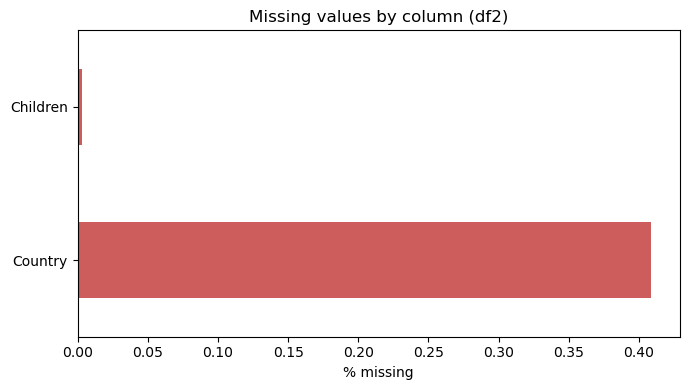

Country     0.408744
Children    0.003350
dtype: float64


In [68]:
# Missingness overview
null_pct = (df2.isnull().sum() / len(df2) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

fig, ax = plt.subplots(figsize=(7, 4))
null_pct.plot(kind='barh', ax=ax, color='indianred')
ax.set_xlabel('% missing')
ax.set_title('Missing values by column (df2)')
plt.tight_layout()
plt.show()
print(null_pct)

In [69]:
df2.duplicated().sum()

31994

In [92]:
# Hotel booking data is known to contain duplicate rows -> drop them
before = df2.shape[0]
df2 = df2.drop_duplicates().reset_index(drop=True)
after = df2.shape[0]
print(f"Dropped {before - after} duplicate rows ({(before - after) / before * 100:.1f}%). New shape: {df2.shape}")

Dropped 31994 duplicate rows (26.8%). New shape: (87396, 31)


In [70]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 31 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   IsCanceled                   119390 non-null  int64  
 1   LeadTime                     119390 non-null  int64  
 2   ArrivalDateYear              119390 non-null  int64  
 3   ArrivalDateMonth             119390 non-null  object 
 4   ArrivalDateWeekNumber        119390 non-null  int64  
 5   ArrivalDateDayOfMonth        119390 non-null  int64  
 6   StaysInWeekendNights         119390 non-null  int64  
 7   StaysInWeekNights            119390 non-null  int64  
 8   Adults                       119390 non-null  int64  
 9   Children                     119386 non-null  float64
 10  Babies                       119390 non-null  int64  
 11  Meal                         119390 non-null  object 
 12  Country                      118902 non-null  object 
 13 

In [100]:
df2['Children'] = df2['Children'].astype(int)

In [101]:
df2['ReservationStatusDate'] = pd.to_datetime(df2['ReservationStatusDate'])

In [71]:
df2.describe()

,IsCanceled,LeadTime,ArrivalDateYear,ArrivalDateWeekNumber,ArrivalDateDayOfMonth,StaysInWeekendNights,StaysInWeekNights,Adults,Children,Babies,IsRepeatedGuest,PreviousCancellations,PreviousBookingsNotCanceled,BookingChanges,DaysInWaitingList,ADR,RequiredCarParkingSpaces,TotalOfSpecialRequests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


In [28]:
# نفس الوقت و نفس الفندق ف ما ادري ينفع احذفهم او لا
df2[df2['children'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40600,City Hotel,1,2,2015,August,32,3,1,0,2,...,No Deposit,NaN,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-01
40667,City Hotel,1,1,2015,August,32,5,0,2,2,...,No Deposit,14.0,NaN,0,Transient-Party,12.0,0,1,Canceled,2015-08-04
40679,City Hotel,1,1,2015,August,32,5,0,2,3,...,No Deposit,NaN,NaN,0,Transient-Party,18.0,0,2,Canceled,2015-08-04
41160,City Hotel,1,8,2015,August,33,13,2,5,2,...,No Deposit,9.0,NaN,0,Transient-Party,76.5,0,1,Canceled,2015-08-09


In [29]:
df2[df2['agent'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
18,Resort Hotel,0,0,2015,July,27,1,0,1,2,...,No Deposit,NaN,110.0,0,Transient,107.42,0,0,Check-Out,2015-07-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119124,City Hotel,0,0,2017,August,35,29,0,1,1,...,No Deposit,NaN,72.0,0,Transient,0.00,0,2,Check-Out,2017-08-30
119151,City Hotel,0,0,2017,August,35,29,0,1,2,...,No Deposit,NaN,NaN,0,Transient,270.00,0,0,Check-Out,2017-08-30
119166,City Hotel,0,0,2017,August,35,30,0,1,1,...,No Deposit,NaN,NaN,0,Transient,140.00,0,0,Check-Out,2017-08-31
119215,City Hotel,0,2,2017,August,35,31,0,1,1,...,No Deposit,NaN,NaN,0,Transient,140.00,0,2,Check-Out,2017-09-01


In [30]:
# ما في نمط محدد بس يمكن اقدر اكتب انه مو معروف 
df2[df2['country'].isnull()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
30,Resort Hotel,0,118,2015,July,27,1,4,10,1,...,No Deposit,NaN,NaN,0,Transient,62.0,0,2,Check-Out,2015-07-15
4127,Resort Hotel,1,0,2016,February,8,15,0,0,0,...,No Deposit,NaN,383.0,0,Transient,0.0,0,0,Canceled,2016-02-15
7092,Resort Hotel,1,8,2016,July,30,21,0,1,1,...,No Deposit,NaN,204.0,0,Transient,73.0,0,2,Canceled,2016-07-20
7860,Resort Hotel,1,39,2016,August,36,30,0,5,2,...,No Deposit,NaN,NaN,0,Transient,159.0,0,5,Canceled,2016-07-22
8779,Resort Hotel,1,0,2016,October,42,13,0,1,1,...,No Deposit,NaN,457.0,0,Transient,50.0,0,0,Canceled,2016-10-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65908,City Hotel,1,0,2017,April,15,10,0,0,0,...,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
65909,City Hotel,1,0,2017,April,15,10,0,0,0,...,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
65910,City Hotel,1,0,2017,April,15,10,0,0,0,...,No Deposit,NaN,279.0,0,Transient,0.0,0,0,Canceled,2017-04-10
80830,City Hotel,0,4,2015,November,48,23,1,2,1,...,No Deposit,37.0,NaN,0,Transient-Party,70.0,0,0,Check-Out,2015-11-26


In [31]:
df2[df2.isnull().sum(axis=1) >= 2]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.0,0,0,Check-Out,2015-07-03
30,Resort Hotel,0,118,2015,July,27,1,4,10,1,...,No Deposit,NaN,NaN,0,Transient,62.0,0,2,Check-Out,2015-07-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119044,City Hotel,0,3,2017,August,34,26,1,1,2,...,No Deposit,NaN,NaN,0,Transient,124.0,0,1,Check-Out,2017-08-28
119046,City Hotel,0,0,2017,August,35,27,1,0,1,...,No Deposit,NaN,NaN,0,Transient,95.0,0,0,Check-Out,2017-08-28
119151,City Hotel,0,0,2017,August,35,29,0,1,2,...,No Deposit,NaN,NaN,0,Transient,270.0,0,0,Check-Out,2017-08-30
119166,City Hotel,0,0,2017,August,35,30,0,1,1,...,No Deposit,NaN,NaN,0,Transient,140.0,0,0,Check-Out,2017-08-31


In [96]:
custom_strategies = {
    'children': 0,        
    'country': 'Unknown', 
    'agent': 0,            
    'company': 0,         
}
df2 = simple_impute(df2, strategies=custom_strategies)
df2.isnull().sum()

IsCanceled                     0
LeadTime                       0
ArrivalDateYear                0
ArrivalDateMonth               0
ArrivalDateWeekNumber          0
ArrivalDateDayOfMonth          0
StaysInWeekendNights           0
StaysInWeekNights              0
Adults                         0
Children                       0
Babies                         0
Meal                           0
Country                        0
MarketSegment                  0
DistributionChannel            0
IsRepeatedGuest                0
PreviousCancellations          0
PreviousBookingsNotCanceled    0
ReservedRoomType               0
AssignedRoomType               0
BookingChanges                 0
DepositType                    0
Agent                          0
Company                        0
DaysInWaitingList              0
CustomerType                   0
ADR                            0
RequiredCarParkingSpaces       0
TotalOfSpecialRequests         0
ReservationStatus              0
Reservatio

In [ ]:
print(df2['category'].unique())

In [ ]:
# What is your target column and what does it represent? Target Column: IsCanceled
#Description: It represents whether a hotel booking was canceled (1) or not canceled (0).
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?

2-Is your target categorical or continuous? Is it balanced (Plot the distribution)?

Type: Categorical (Binary: 0 or 1).
Balance: It is slightly imbalanced (~27% canceled vs ~72% not canceled).

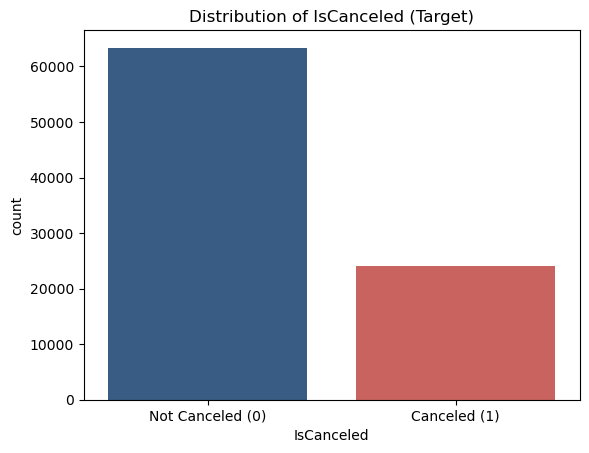

IsCanceled
0    72.511013
1    27.488987
Name: proportion, dtype: float64


In [103]:
sns.countplot(data=df2, x='IsCanceled', palette=['#2b5c8f', '#d9534f'])
plt.title("Distribution of IsCanceled (Target)")
plt.xticks([0, 1], ['Not Canceled (0)', 'Canceled (1)'])
plt.show()

print(df2['IsCanceled'].value_counts(normalize=True) * 100)

What types of features do you have (categorical / numerical)? How many of each?

Total Features: 30 features (excluding target).

Numerical Features (19): 15 integer columns (int64) like LeadTime, Adults, StaysInWeekendNights, and 2 float columns (float64) like ADR, Children.

Categorical Features (12): object columns like Country, MarketSegment, DepositType, CustomerType, Meal, etc

In [105]:
num_cols = df2.select_dtypes(include=['int64', 'float64']).columns.drop('IsCanceled')
cat_cols = df2.select_dtypes(include=['object']).columns

print(f"Numerical features ({len(num_cols)}):", list(num_cols))
print(f"Categorical features ({len(cat_cols)}):", list(cat_cols))

Numerical features (19): ['LeadTime', 'ArrivalDateYear', 'ArrivalDateWeekNumber', 'ArrivalDateDayOfMonth', 'StaysInWeekendNights', 'StaysInWeekNights', 'Adults', 'Babies', 'IsRepeatedGuest', 'PreviousCancellations', 'PreviousBookingsNotCanceled', 'BookingChanges', 'DaysInWaitingList', 'ADR', 'RequiredCarParkingSpaces', 'TotalOfSpecialRequests', 'LeadTime_log', 'LeadTime_scaled', 'ADR_scaled']
Categorical features (12): ['ArrivalDateMonth', 'Meal', 'Country', 'MarketSegment', 'DistributionChannel', 'ReservedRoomType', 'AssignedRoomType', 'DepositType', 'Agent', 'Company', 'CustomerType', 'ReservationStatus']


4. How many null values does each feature have? What's your plan for each?

Country: 488 missing values -> Plan: Impute with 'Unknown' or mode.

Children: 4 missing values -> Plan: Impute with 0 and convert data type to int.

Agent / Company: High missing/NULL counts -> Plan: Replace missing values with 0 (indicating no agent/company used) or convert to categorical flags


> **5. Which features are most correlated with your target, and with each other?**
> * **Highest Positive Correlation with `IsCanceled`:**
> `LeadTime_log` (0.24), `LeadTime` / `LeadTime_scaled` (0.18), and `ADR` (0.13). This confirms that longer advance bookings and higher daily rates increase the likelihood of cancellation.
> * **Highest Negative Correlation with `IsCanceled`:**
> `RequiredCarParkingSpaces` (-0.18) and `TotalOfSpecialRequests` (-0.12), indicating that guests requesting parking or special services are much less likely to cancel.
> * **High Inter-feature Correlation (Multicollinearity):**
> Strong correlations exist between engineered/scaled features (such as `LeadTime` and `LeadTime_scaled` / `LeadTime_log`, or `ADR` and `ADR_scaled`), as well as between stay durations (`StaysInWeekNights` and `StaysInWeekendNights`).
> 
>


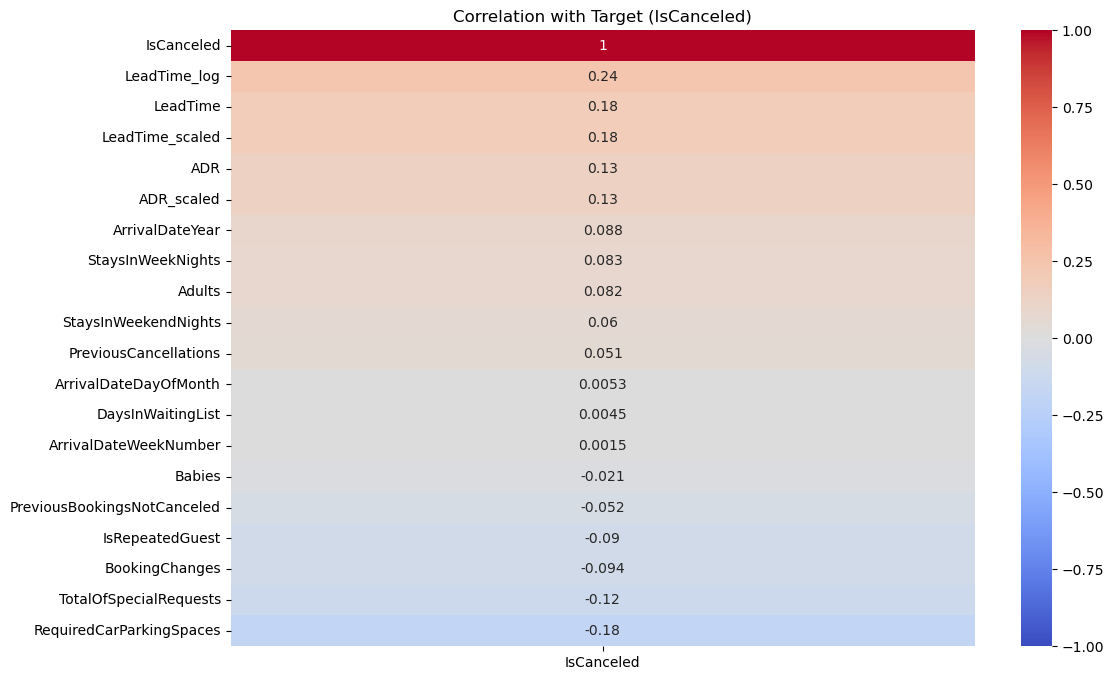

In [106]:
plt.figure(figsize=(12, 8))
numeric_df = df2.select_dtypes(include=['int64', 'float64'])
corr = numeric_df.corr()
sns.heatmap(corr[['IsCanceled']].sort_values(by='IsCanceled', ascending=False), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation with Target (IsCanceled)")
plt.show()

6. Are there outliers? How would you handle them?ا
 Yes, outliers exist in ADR and LeadTime.Handling Strategy:ADR (Average Daily Rate): Remove severe extreme anomalies (e.g., $ADR > 1000$ or $ADR < 0$).LeadTime: Apply Log Transformation (np.log1p) or use Tree-Based Models (like XGBoost/Random Forest) which are robust against outliers without deleting real long-lead customer data.Scaling: Use RobustScaler for distance-based ML models.

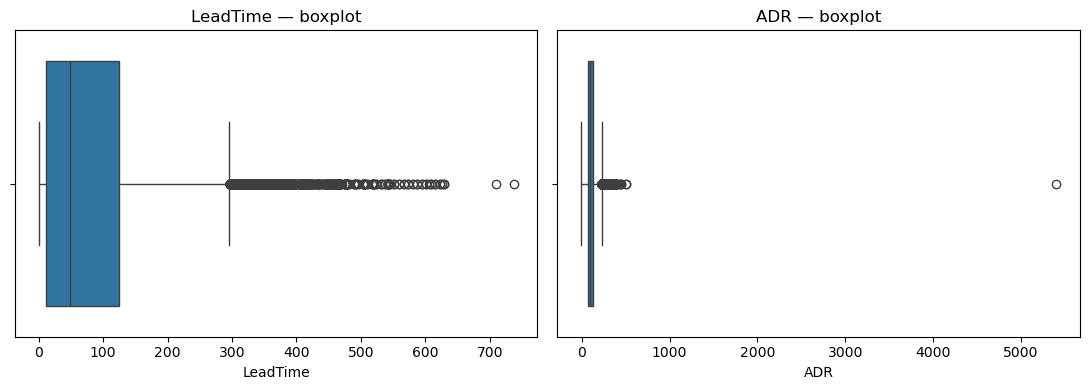

LeadTime: IQR upper bound = 296.00, rows above = 2396
ADR: IQR upper bound = 227.00, rows above = 2490


In [97]:
# Outlier check: lead_time and adr
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df2['LeadTime'], ax=axes[0])
axes[0].set_title('LeadTime — boxplot')

sns.boxplot(x=df2['ADR'], ax=axes[1])
axes[1].set_title('ADR — boxplot')
plt.tight_layout()
plt.show()

for col in ['LeadTime', 'ADR']:
    q1, q3 = df2[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    print(f"{col}: IQR upper bound = {upper:.2f}, rows above = {(df2[col] > upper).sum()}")

In [98]:
df2 = df2[df2['ADR'] < 1000]

df2['LeadTime_log'] = np.log1p(df2['LeadTime'])

from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
df2[['LeadTime_scaled', 'ADR_scaled']] = scaler.fit_transform(df2[['LeadTime', 'ADR']])

# Topic 3 : Real Estate Price Prediction / Valuation


## Problem Statement

Accurately determining residential real estate prices is a critical task for homebuyers, property sellers, real estate agents, and mortgage lenders. Traditional property appraisal methods often rely on manual, time-consuming assessments that can be subject to human bias and local market inefficiencies. 

The primary objective of this project is to develop an automated regression machine learning model to predict single-family home sale prices in King County (Washington State, USA). By leveraging historical sales data—including structural characteristics (living area, bedrooms, bathrooms, construction grade) and spatial features (location coordinates, neighborhood metrics)—the model aims to deliver precise, data-driven property valuations, streamline the appraisal process, and minimize pricing errors for buyers and sellers in the real estate market.

## Data Info
Data Source :https://www.kaggle.com/datasets/harlfoxem/housesalesprediction

## Data Dictionary
| Column         | Type    | Description |
| -------------- | ------- | ------------ |
| id             | int     | Unique house identifier |
| date           | object  | Date the house was sold |
| price          | float   | **Target.** Sale price |
| bedrooms       | int     | Number of bedrooms |
| bathrooms      | float   | Number of bathrooms |
| sqft_living    | int     | Living space square footage |
| sqft_lot       | int     | Lot square footage |
| floors         | float   | Number of floors |
| waterfront     | int     | 1 if property has waterfront view |
| view           | int     | Quality of view (0-4 scale) |
| condition      | int     | Overall condition rating (1-5) |
| grade          | int     | Construction/design quality grade |
| sqft_above     | int     | Square footage above ground |
| sqft_basement  | int     | Square footage of basement |
| yr_built       | int     | Year house was built |
| yr_renovated   | int     | Year renovated (0 if never) |
| zipcode        | int     | Zip code |
| lat / long     | float   | Latitude / longitude |
| sqft_living15  | int     | Living space of nearest 15 neighbors (avg) |
| sqft_lot15     | int     | Lot size of nearest 15 neighbors (avg) |

In [110]:
df3 = pd.read_csv('./Data/kc_house_data.csv')
df3.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [111]:
df3.shape

(21613, 21)

In [113]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [114]:
df3['date'] = pd.to_datetime(df4['date'])

In [115]:
df3['bathrooms'] = df4['bathrooms'].astype(int)

In [116]:
df3['floors'] = df4['floors'].astype(int)

In [117]:
df3.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900.0,3,1,1180,5650,1,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000.0,3,2,2570,7242,2,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000.0,2,1,770,10000,1,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000.0,4,3,1960,5000,1,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000.0,3,2,1680,8080,1,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [118]:
df3.duplicated().sum()

0

In [119]:
df3.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21613,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,...,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,2014-10-29 04:38:01.959931648,5.400881e+05,3.370842,1.749734,2079.899736,1.510697e+04,1.446213,0.007542,0.234303,...,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
min,1.000102e+06,2014-05-02 00:00:00,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,...,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,2014-07-22 00:00:00,3.219500e+05,3.000000,1.000000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,...,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,2014-10-16 00:00:00,4.500000e+05,3.000000,2.000000,1910.000000,7.618000e+03,1.000000,0.000000,0.000000,...,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,2015-02-17 00:00:00,6.450000e+05,4.000000,2.000000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,...,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,2015-05-27 00:00:00,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.000000,1.000000,4.000000,...,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000
std,2.876566e+09,NaN,3.671272e+05,0.930062,0.734873,918.440897,4.142051e+04,0.551894,0.086517,0.766318,...,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631


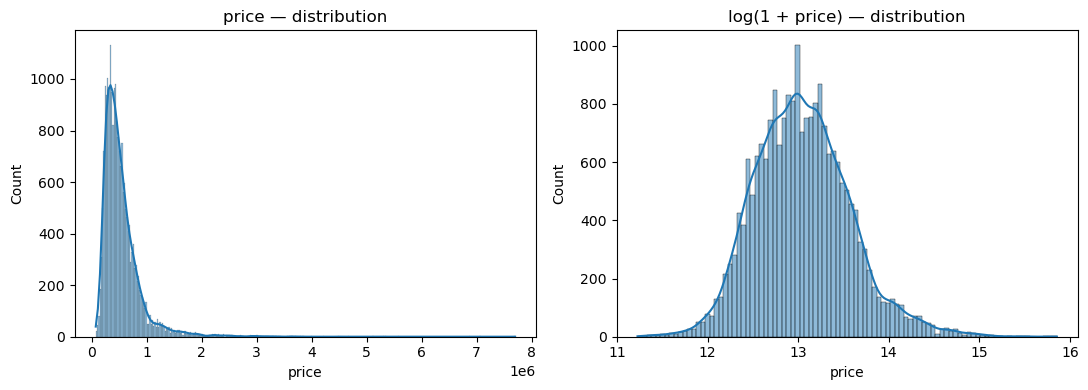

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64


In [120]:
# Target distribution: price
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df3['price'], kde=True, ax=axes[0])
axes[0].set_title('price — distribution')

sns.histplot(np.log1p(df3['price']), kde=True, ax=axes[1])
axes[1].set_title('log(1 + price) — distribution')
plt.tight_layout()
plt.show()

print(df4['price'].describe())

In [123]:
# What is your target column and what does it represent? Target Column: price
#Description: Continuous numerical variable representing the final sale price of the house in US Dollars ($)
# Is your target categorical or continuous? is it balanced (Plot the distribution)?
# What types of features do you have (categorical / numerical)? how many of each ?
# How many null values does each feature have? what's your plan for each?
# Which features are most correlated with your target, and with each other?
# Are there outliers? how would you handle them?

2. Is your target categorical or continuous? Is it balanced (Plot the distribution)?
Type: Continuous.

Distribution: The target is positively skewed (right-skewed), with a median price around $450,000 and extreme high-end luxury properties reaching $7.7M.

Handling Strategy: A Log Transformation (np.log1p(df['price'])) will be applied to normalize the target distribution for linear regression modeling.

Text(0.5, 1.0, 'Price Distribution (Original - Skewed)')

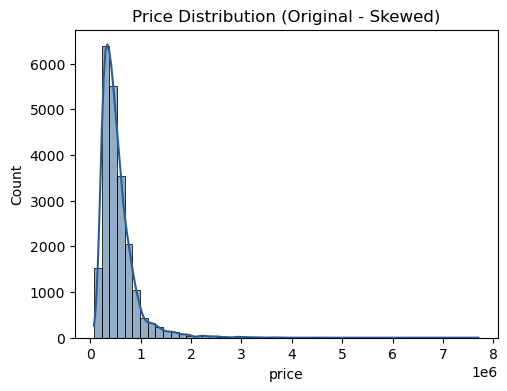

In [124]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df3['price'], bins=50, kde=True, color='#2b5c8f')
plt.title("Price Distribution (Original - Skewed)")


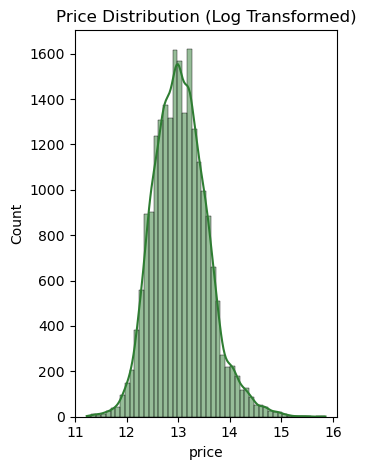

In [125]:

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df3['price']), bins=50, kde=True, color='#2e7d32')
plt.title("Price Distribution (Log Transformed)")
plt.tight_layout()
plt.show()

3. What types of features do you have (categorical / numerical)? How many of each?
Total Features: 20 features (excluding target price).

Numerical Features (18):

Continuous: sqft_living, sqft_lot, sqft_above, sqft_basement, sqft_living15, sqft_lot15, lat, long.

Discrete/Count: bedrooms, bathrooms, floors, view, condition, grade, yr_built, yr_renovated, zipcode, id.

Categorical / DateTime Features (2): date (Transaction Date) and zipcode (can be treated as a spatial categorical feature).

In [128]:
#Numerical Features & Correlation with Target
print("\n--- Top Numerical Correlations with Price ---")
num_df = df3.select_dtypes(include=['int64', 'float64']).drop(columns=['id'], errors='ignore')
corr = num_df.corr()
top_corrs = corr['price'].sort_values(ascending=False)
print(top_corrs)


--- Top Numerical Correlations with Price ---
price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
waterfront       0.266369
yr_renovated     0.126434
sqft_lot         0.089661
sqft_lot15       0.082447
yr_built         0.054012
condition        0.036362
long             0.021626
zipcode         -0.053203
Name: price, dtype: float64


4. How many null values does each feature have? What's your plan for each?

In [112]:
df3.isnull().sum() 

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

5. Which features are most correlated with your target, and with each other?
Highest Positive Correlation with price:

sqft_living (0.70): Larger living area directly drives higher prices.

grade (0.67): Higher construction and design quality strongly increases house value.

sqft_above (0.61) & sqft_living15 (0.59).

bathrooms (0.53).

High Inter-feature Correlation (Multicollinearity):

sqft_living has a very high correlation with sqft_above (0.88) and sqft_living15 (0.76), since sqft_living = sqft_above + sqft_basement.

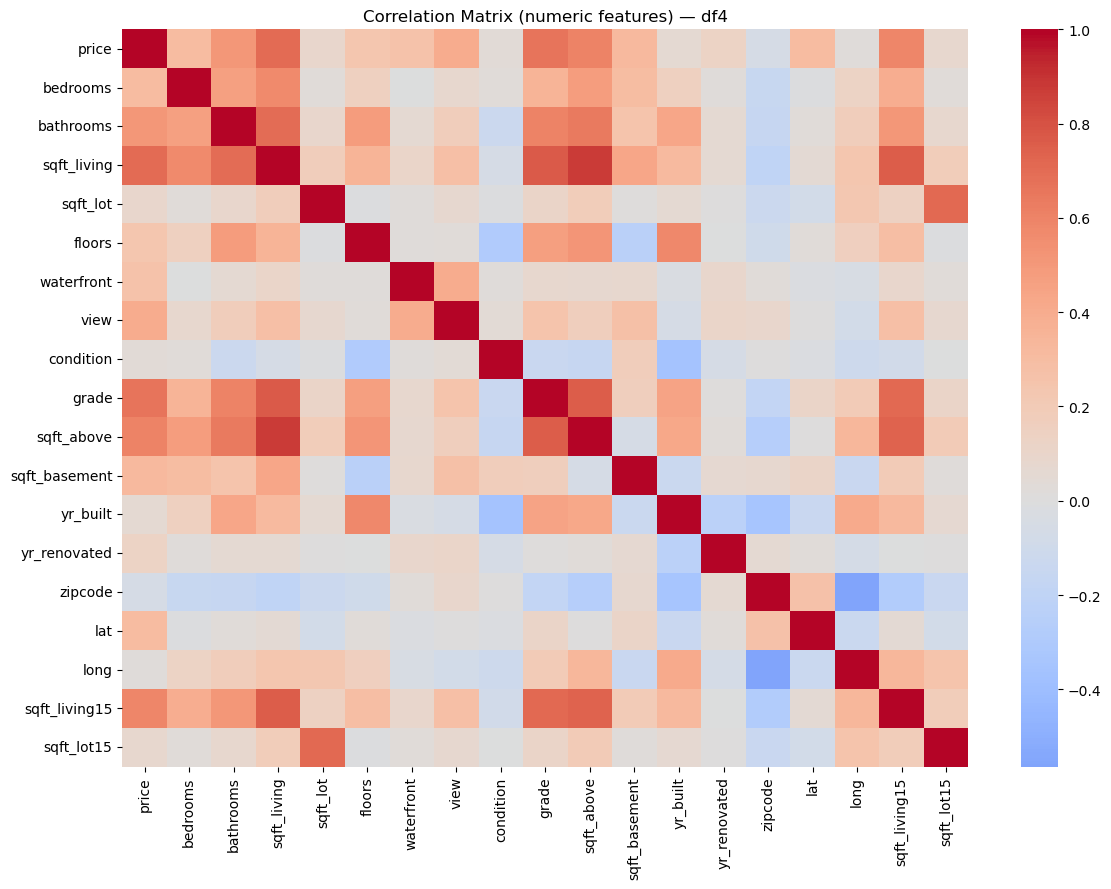

price            1.000000
sqft_living      0.702035
grade            0.667434
sqft_above       0.605567
sqft_living15    0.585379
bathrooms        0.510072
view             0.397293
sqft_basement    0.323816
bedrooms         0.308350
lat              0.307003
Name: price, dtype: float64


In [129]:
# Correlation heatmap of numeric features vs price
num_cols4 = df3.select_dtypes(include=np.number).columns.drop(['id']).tolist()
corr4 = df3[num_cols4].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr4, cmap='coolwarm', center=0)
plt.title('Correlation Matrix (numeric features) — df4')
plt.tight_layout()
plt.show()

print(corr4['price'].sort_values(ascending=False).head(10))

6. Are there outliers? How would you handle them?
Outliers Identified:

Extreme house prices (e.g., $7.7M luxury estates).

Anomaly record: A house with 33 bedrooms but modest sqft_living.

Houses with extreme sqft_lot values (large farmland/rural plots).

Handling Strategy:

Filter out physically impossible or error rows (e.g., fixing or removing the 33-bedroom anomaly).

Apply log transformations to skewed area features (sqft_living, sqft_lot).

Use robust feature scaling (StandardScaler or RobustScaler) and tree-based ensemble models (Random Forest / XGBoost) which naturally handle outliers effectively

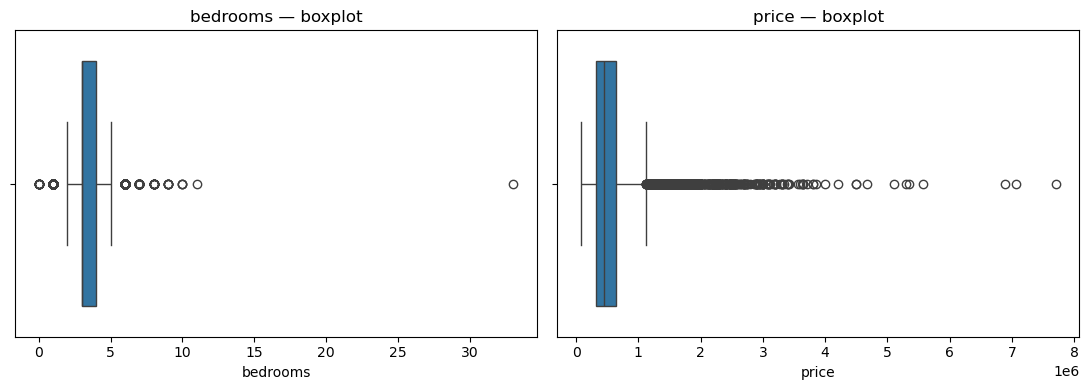

Homes with 10+ bedrooms:
       bedrooms  bathrooms  sqft_living      price
8757         11          3         3000   520000.0
13314        10          5         4590  1148000.0
15161        10          2         3610   650000.0
15870        33          1         1620   640000.0
19254        10          3         2920   660000.0

price: IQR upper bound = 1129575.00, rows above = 1146


In [122]:
# Outlier check: bedrooms (known data quality issue) and price
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(x=df3['bedrooms'], ax=axes[0])
axes[0].set_title('bedrooms — boxplot')

sns.boxplot(x=df3['price'], ax=axes[1])
axes[1].set_title('price — boxplot')
plt.tight_layout()
plt.show()

print("Homes with 10+ bedrooms:")
print(df4[df4['bedrooms'] >= 10][['bedrooms', 'bathrooms', 'sqft_living', 'price']])

q1, q3 = df3['price'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"\nprice: IQR upper bound = {upper:.2f}, rows above = {(df3['price'] > upper).sum()}")